# Monte Carlo (MC)

El **método de Monte Carlo (MC)** es una técnica computacional que utiliza muestreo aleatorio para aproximar soluciones a problemas matemáticos, incluyendo integrales definidas. En Python, se puede implementar este método para calcular integrales generando un gran número de puntos aleatorios dentro de un intervalo dado, evaluando la función en esos puntos, y luego calculando el promedio de los resultados multiplicados por el ancho del intervalo.

El método de Monte Carlo es especialmente útil cuando no hay una solución analítica disponible o cuando la función es muy compleja para ser integrada analíticamente.

**Wiki**: Monte Carlo methods, also called the Monte Carlo experiments or Monte Carlo simulations, are a broad class of computational algorithms based on repeated random sampling for obtaining numerical results. `The underlying concept is to use randomness to solve deterministic problems`. Monte Carlo methods are mainly used in three distinct problem classes:

1. Numerical integration
2. Optimization (MC Markov chain)
3. Non-uniform random variate generation

History:

The name comes from the Monte Carlo Casino in Monaco, where the primary developer of the method, mathematician Stanisław Ulam, was inspired by his uncle's gambling habits.

... in process



In [1]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt

## 1. MC Integration technique

INTRODUCTION: In the following example we show how to compute the $\pi$ number using a random set of points. This idea shows how to compute a quantity using `random numbers`.

$\text{Área del cuadrado}/\text{Área círculo} = \text{All points inside the squared}/\text{All points inside the circle}=N/k$

$$4/\pi(1)^2 = N/k$$

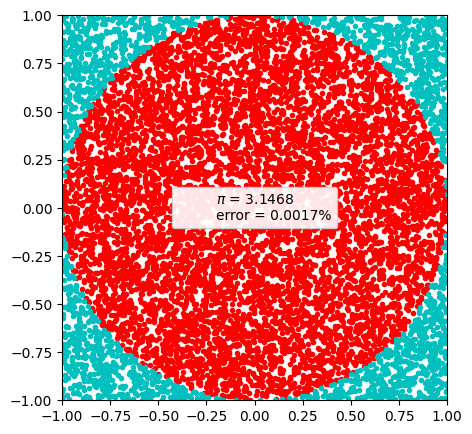

In [ ]:
N = 10000
xmenor = []
ymenor = []
xmayor = []
ymayor = []

k=0
x, y = np.random.uniform(-1, 1, size=(2, N)) # Two arrays: N random in (-1,1)

for i in range(N):

  if x[i]**2+y[i]**2 <= 1: # Numbers inside the unitary circle.
    xmenor.append(x[i])
    ymenor.append(y[i])

    #Al the points inside the circle
    k = k+1

  else:
    xmayor.append(x[i])
    ymayor.append(y[i])

#Pi value: Applicaction of the method
pi = k*4/N
error = abs((pi - np.pi) / np.pi)
#Ploting
plt.figure(figsize=(5,5))
plt.plot(xmenor, ymenor, 'r.')
plt.plot(xmayor, ymayor, 'c.')
plt.plot(0, 0, label='$\\pi$ = {:4.4f}\nerror = {:4.4f}%'.format(pi,error), alpha=0)
plt.axis('square')
plt.legend(frameon=True, framealpha=0.9, fontsize=10)
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.show()

GENERAL RUTINE

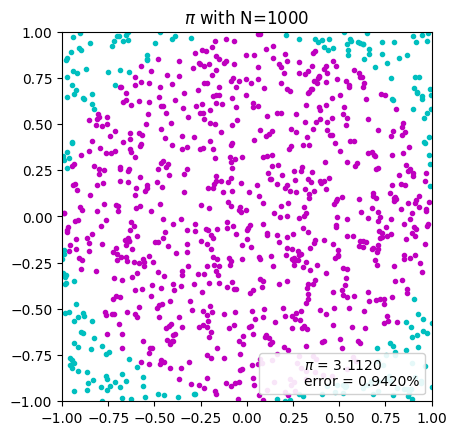

In [2]:
# Ejemplo: Aproximando el valor de pi - área de un círculo de radio = 1. Taken from internet

def mc_pi_aprox(N=1000):
    x, y = np.random.uniform(-1, 1, size=(2, N))
    interior = (x**2 + y**2) <= 1 #if conditional
    pi = interior.sum() * 4/N #suma el contador. Not the sum of the radios
    error = abs((pi - np.pi) / np.pi)*100
    exterior = np.invert(interior)
    plt.plot(x[interior], y[interior], 'm.')
    plt.plot(x[exterior], y[exterior], 'c.')
    plt.plot(0, 0, label='$\\pi$ = {:4.4f}\nerror = {:4.4f}%'.format(pi,error), alpha=0)
    plt.title('$\\pi$ with N=%.d'%N)
    plt.axis('square')
    plt.legend(frameon=True, framealpha=0.9, fontsize=10,loc='lower right')
    plt.xlim(-1,1)
    plt.ylim(-1,1)

mc_pi_aprox()

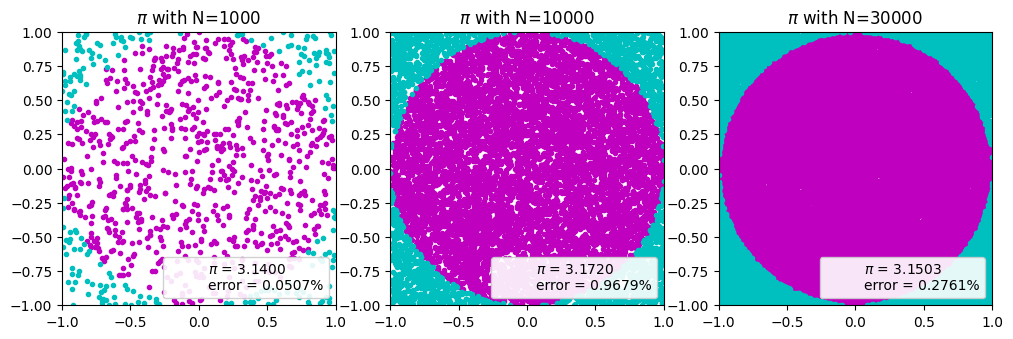

In [3]:
plt.figure(figsize=(12,5))

plt.subplot(131)
mc_pi_aprox(N=1000)

plt.subplot(132)
mc_pi_aprox(N=10000)

plt.subplot(133)
mc_pi_aprox(N=30000)

## Monte Carlo Integration technique

General for compute and integral:

$\int_a^b f(x) dx = \langle f(x) \rangle (b-a) \approx (b-a)\times \sum_{i=1}^N f(x_i)/N$

Idea: $\text{Área promedio} = \text{Área aleatoria / N}$.

In [4]:
#General rutine
def monte_carlo_integration(func, a, b, num_samples=1000):
    """
    Aproxima la integral definida de una función utilizando el método de Monte Carlo.

    Args:
        func: La función a integrar (debe ser una función de Python).
        a: El límite inferior de integración.
        b: El límite superior de integración.
        num_samples: El número de puntos aleatorios a generar.

    Returns:
        Una aproximación de la integral definida.
    """
    integral_sum = 0
    for _ in range(num_samples):
        # Generar un punto aleatorio en el intervalo [a, b]
        x = random.uniform(a, b)
        # Sumar el valor de la función en ese punto
        integral_sum += func(x)
    # Calcular el promedio y multiplicar por el ancho del intervalo
    integral_approx = (b - a) * (integral_sum / num_samples)
    return integral_approx

### Example 1:

$\int_0^2 x^2 dx = (x^{3}/3)|_0^2=8/3≈2.\bar{6}$

In [5]:
import scipy.integrate as integrate

def f(x):
  return x**2

integrate.quad(f,0,2)

(2.666666666666667, 2.960594732333751e-14)

In [6]:
# Definir los límites de integración y el número de muestras
a = 0
b = 2
num_samples = 100000
# Compute the integral using MonteCarlo
integral_result = monte_carlo_integration(f, a, b, num_samples)

print(f"MonteCarlo value: {integral_result}")
print(f"Analytical result : {8/3}")
print('error', abs(integral_result-8/3))

MonteCarlo value: 2.6682425825006817
Analytical result : 2.6666666666666665
error 0.0015759158340151735


In [7]:
for i in range(500,10000,1000):
    # Calcular la aproximación de la integral
    integral_result = monte_carlo_integration(f, a, b, i)
    print(i,'samples:',f"Aproximación de la integral: {integral_result}")

print(f"\nAnalytical value: {8/3}")

500 samples: Aproximación de la integral: 2.6028717779026596
1500 samples: Aproximación de la integral: 2.652582425342642
2500 samples: Aproximación de la integral: 2.679937161190003
3500 samples: Aproximación de la integral: 2.687252500272907
4500 samples: Aproximación de la integral: 2.654552396602035
5500 samples: Aproximación de la integral: 2.656949555663526
6500 samples: Aproximación de la integral: 2.668012140053227
7500 samples: Aproximación de la integral: 2.693636883897092
8500 samples: Aproximación de la integral: 2.68394035601341
9500 samples: Aproximación de la integral: 2.640357472080531

Analytical value: 2.6666666666666665


### Example 2:

$\int_0^{\pi}\, \sin(x) dx = (-\cos(x))|_0^{\pi}=2$ ... using MC.

https://www.geeksforgeeks.org/python/monte-carlo-integration-in-python/

In [10]:
def f(x):
    return np.sin(x)

integral_result = monte_carlo_integration(f, 0, np.pi, 2000)

print(f"Aproximation with MC: {integral_result}")

Aproximation with MC: 2.03221825446756


In [ ]:
for i in range(10):
  print(monte_carlo_integration(f, 0, np.pi, 2000))

2.03408993316827
1.9939499485658043
1.9618850529833596
2.03102210261625
1.9735699686523447
1.9839973273811682
1.9998967858757104
2.0313934240367795
1.9818156752149914
2.0033462068100194


The value is very close to the answer of the integral which is 2.0.

### Histogram

Now if we want to visualize the integration using a histogram, we can do so by using the matplotlib library. Again we import the modules, define the limits of integration and write the sin function for calculating the sin value for a particular value of x. Next, we take an array that has variables representing every beam of the histogram. Then we iterate through N values and repeat the same process of creating a zeros array, filling it with random x values, creating an integral variable adding up all the function values, and getting the answer N times, each answer representing a beam of the histogram. The code is as follows:

The value of the integral is= 2.0323908424268273


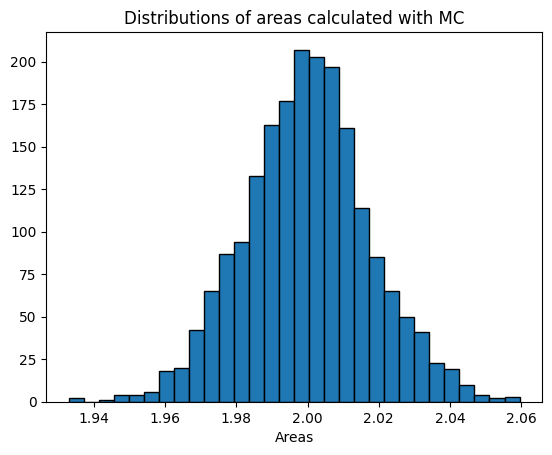

In [12]:
# importing the modules
#from scipy import random
#import numpy as np
#import matplotlib.pyplot as plt

# limits of integration
a, b, N, num_samples = 0, np.pi, 2000, 3000

# function
def f(x):
    return np.sin(x)

# list to store all the values for plotting
plt_vals = []

# we iterate through all the values to generate
# multiple results and show whose intensity is the most.
for i in range(N):

    #Compute the value of the integral for i-esimo time
    ans = monte_carlo_integration( f, a, b, num_samples)

    # appends the solution to a list for plotting the graph
    plt_vals.append(ans)

print('The value of the integral is=',ans)

# details of the plot to be generated
plt.title("Distributions of areas calculated with MC")
plt.hist (plt_vals, bins=30, ec="black")
plt.xlabel("Areas")
plt.show()